## 0. Notebook Objective & Scope
Evaluate whether gradient-boosted tree models (XGBoost, LightGBM) provide a meaningful improvement over the classical baselines established in Notebook 3 across the four Track A cardiovascular prediction tasks (Cath, LAD, LCX, RCA). Experiments evaluate Preprocessing Configuration A (Ordinal VHD, 56 features) and Configuration B (One-Hot VHD, 59 features) strictly on the 242-row development cohort via target-specific Repeated Stratified 5-Fold CV (25 evaluations per configuration, totaling 400 fits). The 61-row holdout test set remains sealed until Notebook 6.

## 1. Reproducibility & Environment
Log library versions and set the global random seed for deterministic cross-validation.

In [1]:
import json
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb
from lightgbm import LGBMClassifier
from scipy.stats import pearsonr, spearmanr
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)

print(f"XGBoost version:    {xgb.__version__}")
print(f"LightGBM version:   {lgb.__version__}")
print(f"scikit-learn:       {sklearn.__version__}")
print(f"pandas version:     {pd.__version__}")
print(f"NumPy version:      {np.__version__}")

XGBoost version:    3.2.0
LightGBM version:   4.6.0
scikit-learn:       1.7.2
pandas version:     2.3.3
NumPy version:      2.3.5


## 2. Load Frozen Dataset Contract
Load raw patient records and verify alignment with the locked findings from Notebooks 1 and 2.

In [2]:
with open('preprocessing_config.json', 'r') as f:
    config = json.load(f)

DATA_PATH = Path('extention of Z-Alizadeh sani dataset.xlsx')
df_raw = pd.read_excel(DATA_PATH)
df = df_raw.copy()

df['Sex'] = df['Sex'].replace({'Fmale': 'Female'})
df = df.drop(columns=config['dropped_features'])

TARGET_COLUMNS = config['target_columns']
TARGET_MAPPINGS = config['target_mappings']

y_df = pd.DataFrame(index=df.index)
for target in TARGET_COLUMNS:
    y_df[target] = df[target].map(TARGET_MAPPINGS[target]).astype(int)

X_raw = df.drop(columns=TARGET_COLUMNS).copy()

print(f"Cleaned cohort: {len(X_raw)} rows, {X_raw.shape[1]} candidate features")
assert not any(t in X_raw.columns for t in TARGET_COLUMNS), "Target leakage in X_raw"

Cleaned cohort: 303 rows, 54 candidate features


## 3. Development / Holdout Partition Verification
Verify that the 80/20 train/holdout split is identical to Notebook 2 and that the 61-row holdout set is completely sealed.

In [3]:
train_indices = config['train_indices']
holdout_indices = config['holdout_indices']

X_dev = X_raw.iloc[train_indices].copy().reset_index(drop=True)
y_dev = y_df.iloc[train_indices].copy().reset_index(drop=True)

X_holdout = X_raw.iloc[holdout_indices].copy().reset_index(drop=True)
y_holdout = y_df.iloc[holdout_indices].copy().reset_index(drop=True)

assert len(X_dev) == 242, f"Expected 242 development records, got {len(X_dev)}"
assert len(X_holdout) == 61, f"Expected 61 holdout records, got {len(X_holdout)}"
assert len(set(train_indices) & set(holdout_indices)) == 0, "Index overlap detected"

print("HOLDOUT STATUS: SEALED & UNTOUCHED (N=61). All evaluations in this notebook strictly use Development (N=242).")

HOLDOUT STATUS: SEALED & UNTOUCHED (N=61). All evaluations in this notebook strictly use Development (N=242).


## 4. Feature & Target Contract Verification
Map the four clinical prediction tasks and inspect positive class prevalence on the development set.

In [4]:
TARGETS = {
    'Cath': {'label': 'Overall CAD', 'pos_class': 'CAD', 'dev_pos_pct': y_dev['Cath'].mean() * 100},
    'LAD':  {'label': 'LAD Stenosis', 'pos_class': 'Stenotic', 'dev_pos_pct': y_dev['LAD'].mean() * 100},
    'LCX':  {'label': 'LCX Stenosis', 'pos_class': 'Stenotic', 'dev_pos_pct': y_dev['LCX'].mean() * 100},
    'RCA':  {'label': 'RCA Stenosis', 'pos_class': 'Stenotic', 'dev_pos_pct': y_dev['RCA'].mean() * 100}
}
display(pd.DataFrame(TARGETS).T)

,label,pos_class,dev_pos_pct
Cath,Overall CAD,CAD,71.487603
LAD,LAD Stenosis,Stenotic,59.090909
LCX,LCX Stenosis,Stenotic,38.429752
RCA,RCA Stenosis,Stenotic,38.842975


## 5. Target-Specific Cross-Validation Strategy
Configure independent RepeatedStratifiedKFold splitters for each target (5 splits x 5 repeats = 25 evaluations).

In [5]:
TARGET_CV_SPLITTERS = {
    target: RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
    for target in TARGET_COLUMNS
}
print("Target-specific RepeatedStratifiedKFold splitters initialized for all 4 targets.")

Target-specific RepeatedStratifiedKFold splitters initialized for all 4 targets.


## 6. Preprocessing Configurations (Config A vs Config B)
Reconstruct modular ColumnTransformers for Config A (Ordinal VHD, 56 features) and Config B (One-Hot VHD, 59 features).

In [6]:
fg = config['feature_groups']

ALL_NUMERIC_FEATURES = fg['all_numeric_features']
BINARY_STR_FEATURES = fg['binary_str_features']
BINARY_NUM_FEATURES = fg['binary_num_features']
SEX_FEATURE = fg['sex_feature']
NOMINAL_FEATURES = fg['nominal_features']
ORDINAL_CAT_FEATURES = fg['ordinal_cat_features']

numeric_pipeline = Pipeline([('scaler', StandardScaler())])

binary_str_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['N', 'Y']] * len(BINARY_STR_FEATURES),
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

sex_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['Female', 'Male']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

bbb_pipeline = Pipeline([
    ('ohe', OneHotEncoder(
        categories=[['N', 'LBBB', 'RBBB']],
        handle_unknown='ignore',
        sparse_output=False
    ))
])

vhd_ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['N', 'mild', 'Moderate', 'Severe']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

vhd_onehot_pipeline = Pipeline([
    ('ohe', OneHotEncoder(
        categories=[['N', 'mild', 'Moderate', 'Severe']],
        handle_unknown='ignore',
        sparse_output=False
    ))
])

def build_preprocessor(vhd_mode='ordinal'):
    vhd_pipe = vhd_ordinal_pipeline if vhd_mode == 'ordinal' else vhd_onehot_pipeline
    transformers = [
        ('num', numeric_pipeline, ALL_NUMERIC_FEATURES),
        ('bin_str', binary_str_pipeline, BINARY_STR_FEATURES),
        ('sex', sex_pipeline, SEX_FEATURE),
        ('bbb', bbb_pipeline, NOMINAL_FEATURES),
        ('vhd', vhd_pipe, ORDINAL_CAT_FEATURES),
        ('bin_num', 'passthrough', BINARY_NUM_FEATURES)
    ]
    return ColumnTransformer(transformers=transformers, remainder='drop')

PREPROCESSORS = {
    'Config_A_Ordinal': build_preprocessor(vhd_mode='ordinal'),
    'Config_B_OneHot': build_preprocessor(vhd_mode='onehot')
}

for name, prep in PREPROCESSORS.items():
    prep.fit(X_dev)
    n_feats = len(prep.get_feature_names_out())
    print(f"{name:20s}: Transformed output features = {n_feats}")
    if name == 'Config_A_Ordinal':
        assert n_feats == 56, f"Expected 56 features for Config A, got {n_feats}"
    else:
        assert n_feats == 59, f"Expected 59 features for Config B, got {n_feats}"

Config_A_Ordinal    : Transformed output features = 56
Config_B_OneHot     : Transformed output features = 59


## 7. XGBoost Baseline Configuration
Conservative baseline configuration tailored for small tabular clinical data (shallow depth, regularized).

In [7]:
xgb_baseline = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("XGBoost Baseline Model initialized (shallow trees max_depth=3, regularized).")

XGBoost Baseline Model initialized (shallow trees max_depth=3, regularized).


## 8. LightGBM Baseline Configuration
Conservative baseline configuration tailored for small cohorts (restricted leaves, min_child_samples=20).

In [8]:
lgb_baseline = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)
print("LightGBM Baseline Model initialized (num_leaves=15, min_child_samples=20).")

BOOSTING_MODELS = {
    'XGBoost': xgb_baseline,
    'LightGBM': lgb_baseline
}

LightGBM Baseline Model initialized (num_leaves=15, min_child_samples=20).


## 9. Leakage-Safe Pipeline Construction
Encapsulate preprocessor and boosting estimator inside sklearn Pipeline so transformers fit strictly on training folds.

In [9]:
print("Pipeline architecture: ColumnTransformer -> Estimator inside Pipeline. No pre-CV transformation.")

Pipeline architecture: ColumnTransformer -> Estimator inside Pipeline. No pre-CV transformation.


## 10. Generic Boosting Evaluation Engine
Evaluates pipelines across repeated stratified folds, logging accuracy, precision, recall, F1, ROC-AUC, and PR-AUC.

In [10]:
def evaluate_boosting_pipeline(pipeline, X, y, cv_splitter, target_name, model_name, prep_name):
    records = []
    rep1_oof_predictions = np.zeros(len(X))
    rep1_oof_probabilities = np.zeros(len(X))
    fold_counter = 0

    for fold_idx, (train_i, val_i) in enumerate(cv_splitter.split(X, y)):
        fold_counter += 1
        repeat_num = (fold_idx // 5) + 1
        fold_num = (fold_idx % 5) + 1

        X_tr, y_tr = X.iloc[train_i], y.iloc[train_i]
        X_va, y_val = X.iloc[val_i], y.iloc[val_i]

        fold_pipe = clone(pipeline)
        fold_pipe.fit(X_tr, y_tr)

        y_prob = fold_pipe.predict_proba(X_va)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        auc = roc_auc_score(y_val, y_prob)
        pr_auc = average_precision_score(y_val, y_prob)

        records.append({
            'target': target_name,
            'model': model_name,
            'preprocessing': prep_name,
            'evaluation_idx': fold_counter,
            'repeat': repeat_num,
            'fold': fold_num,
            'train_size': len(train_i),
            'val_size': len(val_i),
            'positive_train': int(y_tr.sum()),
            'negative_train': int(len(y_tr) - y_tr.sum()),
            'positive_val': int(y_val.sum()),
            'negative_val': int(len(y_val) - y_val.sum()),
            'roc_auc': auc,
            'pr_auc': pr_auc,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1
        })

        if fold_idx < 5:
            rep1_oof_predictions[val_i] = y_pred
            rep1_oof_probabilities[val_i] = y_prob

    return pd.DataFrame(records), rep1_oof_predictions, rep1_oof_probabilities

## 11. Experiment Matrix & Execution
Execute 16 configurations (4 targets x 2 preprocessing configs x 2 boosting models) across 25 folds = 400 fitted pipelines.

In [11]:
all_boosting_results = []
rep1_oof_dict = {}

config_idx = 0
print("Beginning 16 boosting configurations across 25 folds (400 pipeline fits)...")

for target in TARGET_COLUMNS:
    y_target = y_dev[target]
    cv_splitter = TARGET_CV_SPLITTERS[target]

    for prep_name, prep_obj in PREPROCESSORS.items():
        for model_name, model_obj in BOOSTING_MODELS.items():
            config_idx += 1
            pipe = Pipeline([
                ('preprocessor', prep_obj),
                ('model', model_obj)
            ])

            res_df, oof_pred, oof_prob = evaluate_boosting_pipeline(
                pipe, X_dev, y_target, cv_splitter,
                target_name=target, model_name=model_name, prep_name=prep_name
            )
            all_boosting_results.append(res_df)
            oof_key = f"{target}__{prep_name}__{model_name}"
            rep1_oof_dict[oof_key] = {'pred': oof_pred, 'prob': oof_prob}

boosting_results_df = pd.concat(all_boosting_results, ignore_index=True)
print(f"Execution complete! Total fold evaluations logged: {len(boosting_results_df)}")
assert len(boosting_results_df) == 400, f"Expected 400 fold records, got {len(boosting_results_df)}"

Beginning 16 boosting configurations across 25 folds (400 pipeline fits)...

Execution complete! Total fold evaluations logged: 400


## 12. Aggregate Performance Results
Mean, standard deviation, median, and IQR across all 25 evaluations for each boosting configuration.

In [12]:
agg_funcs = {
    'roc_auc': ['mean', 'std', 'median', lambda x: x.quantile(0.75) - x.quantile(0.25), 'min', 'max'],
    'f1': ['mean', 'std', 'median'],
    'recall': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'accuracy': ['mean', 'std'],
    'pr_auc': ['mean', 'std']
}

summary_df = boosting_results_df.groupby(['target', 'preprocessing', 'model']).agg(
    roc_auc_mean=('roc_auc', 'mean'),
    roc_auc_std=('roc_auc', 'std'),
    roc_auc_median=('roc_auc', 'median'),
    roc_auc_iqr=('roc_auc', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    roc_auc_min=('roc_auc', 'min'),
    roc_auc_max=('roc_auc', 'max'),
    f1_mean=('f1', 'mean'),
    f1_std=('f1', 'std'),
    recall_mean=('recall', 'mean'),
    recall_std=('recall', 'std'),
    precision_mean=('precision', 'mean'),
    precision_std=('precision', 'std'),
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
    pr_auc_mean=('pr_auc', 'mean'),
    pr_auc_std=('pr_auc', 'std')
).reset_index()

summary_formatted = summary_df.copy()
for m in ['roc_auc', 'f1', 'recall', 'precision', 'accuracy', 'pr_auc']:
    summary_formatted[m] = summary_formatted.apply(
        lambda r: f"{r[m+'_mean']:.3f} +/- {r[m+'_std']:.3f}", axis=1
    )

display_cols = ['target', 'preprocessing', 'model', 'roc_auc', 'f1', 'recall', 'precision', 'accuracy', 'pr_auc']
display(summary_formatted[display_cols].sort_values(['target', 'roc_auc'], ascending=[True, False]))

,target,preprocessing,model,roc_auc,f1,recall,precision,accuracy,pr_auc
3,Cath,Config_B_OneHot,XGBoost,0.925 +/- 0.039,0.914 +/- 0.028,0.936 +/- 0.042,0.895 +/- 0.037,0.874 +/- 0.040,0.966 +/- 0.024
1,Cath,Config_A_Ordinal,XGBoost,0.924 +/- 0.037,0.913 +/- 0.026,0.932 +/- 0.046,0.897 +/- 0.032,0.873 +/- 0.037,0.966 +/- 0.022
0,Cath,Config_A_Ordinal,LightGBM,0.918 +/- 0.037,0.907 +/- 0.030,0.927 +/- 0.050,0.891 +/- 0.039,0.865 +/- 0.043,0.962 +/- 0.023
2,Cath,Config_B_OneHot,LightGBM,0.918 +/- 0.036,0.907 +/- 0.027,0.928 +/- 0.045,0.888 +/- 0.037,0.864 +/- 0.038,0.961 +/- 0.025
5,LAD,Config_A_Ordinal,XGBoost,0.831 +/- 0.051,0.808 +/- 0.038,0.824 +/- 0.048,0.794 +/- 0.051,0.768 +/- 0.047,0.861 +/- 0.047
7,LAD,Config_B_OneHot,XGBoost,0.829 +/- 0.053,0.809 +/- 0.038,0.821 +/- 0.052,0.801 +/- 0.054,0.771 +/- 0.047,0.861 +/- 0.053
4,LAD,Config_A_Ordinal,LightGBM,0.827 +/- 0.051,0.813 +/- 0.038,0.820 +/- 0.053,0.809 +/- 0.046,0.778 +/- 0.046,0.859 +/- 0.045
6,LAD,Config_B_OneHot,LightGBM,0.826 +/- 0.048,0.810 +/- 0.044,0.818 +/- 0.057,0.804 +/- 0.050,0.773 +/- 0.053,0.856 +/- 0.046
11,LCX,Config_B_OneHot,XGBoost,0.750 +/- 0.064,0.549 +/- 0.095,0.515 +/- 0.131,0.610 +/- 0.102,0.684 +/- 0.053,0.652 +/- 0.084
9,LCX,Config_A_Ordinal,XGBoost,0.747 +/- 0.063,0.557 +/- 0.090,0.521 +/- 0.128,0.618 +/- 0.093,0.689 +/- 0.049,0.650 +/- 0.080


## 13. Preprocessing Sensitivity for Boosting Models
Quantify the impact of Ordinal VHD (Config A) vs One-Hot VHD (Config B) on XGBoost and LightGBM. Across all tested boosting configurations, the largest observed absolute mean ROC-AUC difference between Config A and B is 0.0102 (observed on LCX with LightGBM). Preprocessing effects remain target- and algorithm-dependent rather than following a uniform trend.

In [13]:
pivot_auc = summary_df.pivot_table(
    index=['target', 'model'],
    columns='preprocessing',
    values='roc_auc_mean'
)
pivot_auc['delta_auc (B - A)'] = (pivot_auc['Config_B_OneHot'] - pivot_auc['Config_A_Ordinal']).round(4)

pivot_f1 = summary_df.pivot_table(
    index=['target', 'model'],
    columns='preprocessing',
    values='f1_mean'
)
pivot_f1['delta_f1 (B - A)'] = (pivot_f1['Config_B_OneHot'] - pivot_f1['Config_A_Ordinal']).round(4)

prep_sens_df = pivot_auc[['Config_A_Ordinal', 'Config_B_OneHot', 'delta_auc (B - A)']].copy()
prep_sens_df.columns = ['A_ROC_AUC', 'B_ROC_AUC', 'Delta_ROC_AUC']
prep_sens_df['A_F1'] = pivot_f1['Config_A_Ordinal'].round(4)
prep_sens_df['B_F1'] = pivot_f1['Config_B_OneHot'].round(4)
prep_sens_df['Delta_F1'] = pivot_f1['delta_f1 (B - A)'].round(4)

print("Boosting Preprocessing Sensitivity (Candidate A Ordinal vs Candidate B One-Hot):")
display(prep_sens_df)

Boosting Preprocessing Sensitivity (Candidate A Ordinal vs Candidate B One-Hot):


A_ROC_AUC  B_ROC_AUC  Delta_ROC_AUC    A_F1    B_F1  Delta_F1
target model                                                                  
Cath   LightGBM   0.918178   0.918304         0.0001  0.9075  0.9066   -0.0009
       XGBoost    0.923649   0.924676         0.0010  0.9130  0.9141    0.0011
LAD    LightGBM   0.826963   0.826321        -0.0006  0.8131  0.8099   -0.0031
       XGBoost    0.830936   0.828610        -0.0023  0.8075  0.8092    0.0017
LCX    LightGBM   0.738563   0.728382        -0.0102  0.5420  0.5521    0.0101
       XGBoost    0.747422   0.750285         0.0029  0.5570  0.5493   -0.0078
RCA    LightGBM   0.680794   0.685972         0.0052  0.5054  0.5110    0.0057
       XGBoost    0.685971   0.682482        -0.0035  0.4919  0.4927    0.0009

## 14. Boosting vs Notebook 3 Classical Baselines
Direct empirical comparison between the best classical baseline from Notebook 3 and the best boosting model from Notebook 4.

In [14]:
# Load Notebook 3 baseline summary
nb3_summary = pd.read_csv('artifacts/notebook3_baseline_summary.csv')

comparison_records = []

for target in TARGET_COLUMNS:
    # Best baseline from Notebook 3
    base_target = nb3_summary[nb3_summary['target'] == target]
    best_base = base_target.sort_values('roc_auc_mean', ascending=False).iloc[0]

    # Best boosting from Notebook 4
    boost_target = summary_df[summary_df['target'] == target]
    best_boost = boost_target.sort_values('roc_auc_mean', ascending=False).iloc[0]

    delta_auc = best_boost['roc_auc_mean'] - best_base['roc_auc_mean']
    delta_f1 = best_boost['f1_mean'] - best_base['f1_mean']
    delta_rec = best_boost['recall_mean'] - best_base['recall_mean']
    delta_pr = best_boost['pr_auc_mean'] - best_base['pr_auc_mean']

    comparison_records.append({
        'Target': target,
        'Best Baseline (NB3)': f"{best_base['model']} ({best_base['preprocessing']})",
        'Baseline ROC-AUC': round(best_base['roc_auc_mean'], 3),
        'Best Boosting (NB4)': f"{best_boost['model']} ({best_boost['preprocessing']})",
        'Boosting ROC-AUC': round(best_boost['roc_auc_mean'], 3),
        'Delta ROC-AUC': round(delta_auc, 3),
        'Baseline F1': round(best_base['f1_mean'], 3),
        'Boosting F1': round(best_boost['f1_mean'], 3),
        'Delta F1': round(delta_f1, 3),
        'Delta Recall': round(delta_rec, 3),
        'Delta PR-AUC': round(delta_pr, 3)
    })

vs_baseline_df = pd.DataFrame(comparison_records)
display(vs_baseline_df)

,Target,Best Baseline (NB3),Baseline ROC-AUC,Best Boosting (NB4),Boosting ROC-AUC,Delta ROC-AUC,Baseline F1,Boosting F1,Delta F1,Delta Recall,Delta PR-AUC
0,Cath,RandomForest (Config_B_OneHot),0.932,XGBoost (Config_B_OneHot),0.925,-0.008,0.912,0.914,0.002,-0.010,-0.005
1,LAD,RandomForest (Config_A_Ordinal),0.854,XGBoost (Config_A_Ordinal),0.831,-0.023,0.845,0.808,-0.037,-0.075,-0.020
2,LCX,RandomForest (Config_B_OneHot),0.745,XGBoost (Config_B_OneHot),0.750,0.005,0.501,0.549,0.048,0.103,0.004
3,RCA,LogisticRegression (Config_A_Ordinal),0.719,LightGBM (Config_B_OneHot),0.686,-0.033,0.546,0.511,-0.035,-0.035,-0.067


## 15. Stability & Distribution Visualizations
Compare ROC-AUC and F1 distributions across baselines and boosting models, and export figures.

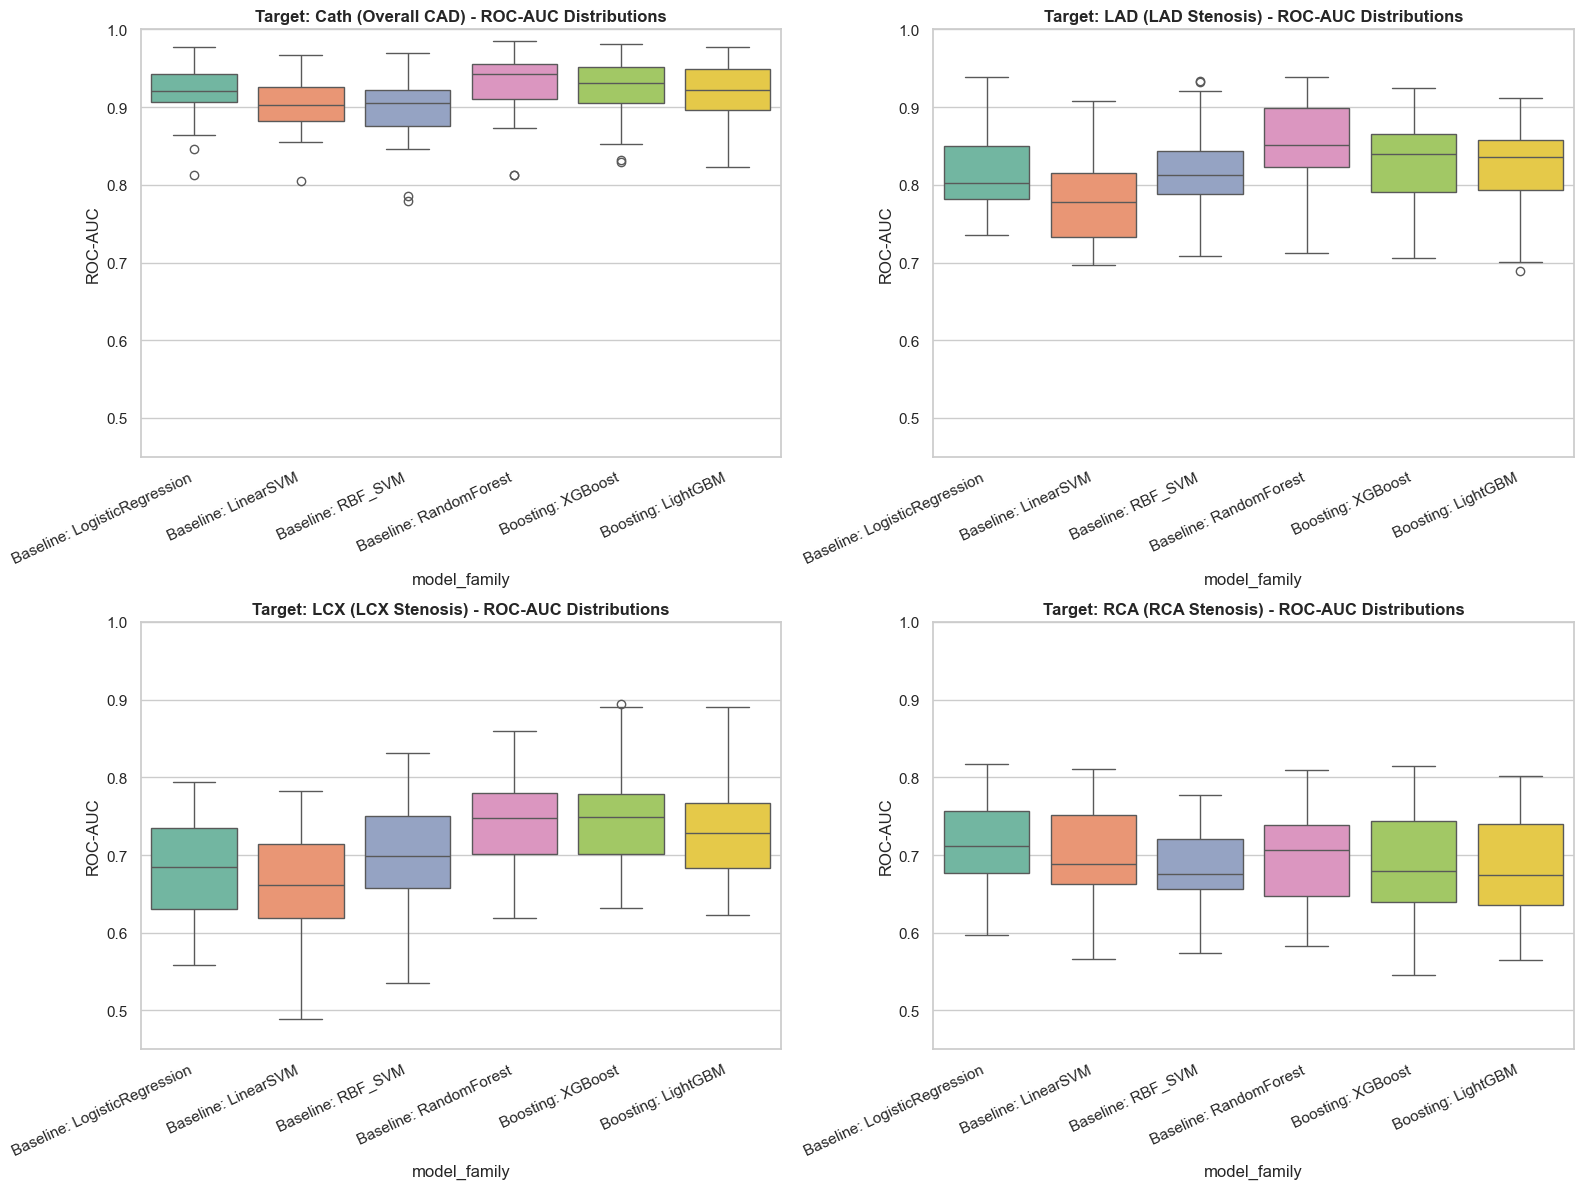

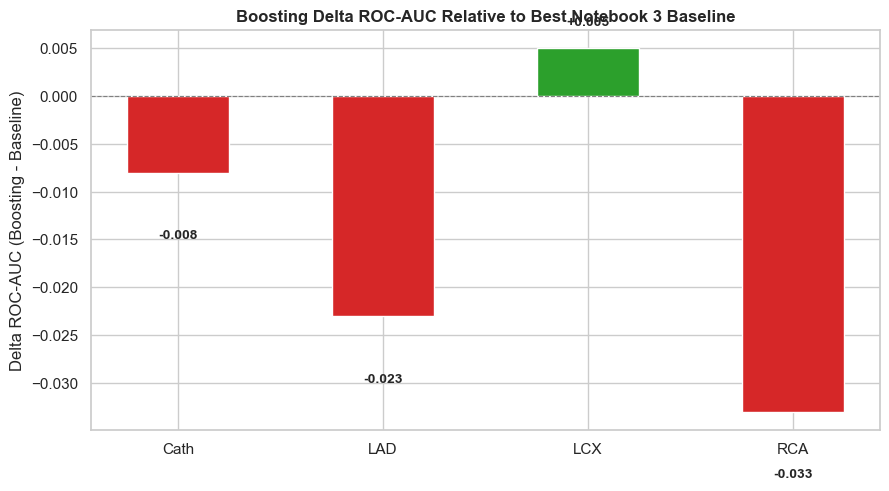

In [15]:
Path('artifacts/figures').mkdir(parents=True, exist_ok=True)

# Load full baseline fold results for unified plotting
nb3_fold_results = pd.read_csv('artifacts/notebook3_baseline_fold_results.csv')
nb3_fold_results['model_family'] = 'Baseline: ' + nb3_fold_results['model']
boosting_results_df['model_family'] = 'Boosting: ' + boosting_results_df['model']

unified_results = pd.concat([
    nb3_fold_results[['target', 'model_family', 'preprocessing', 'roc_auc', 'f1', 'recall']],
    boosting_results_df[['target', 'model_family', 'preprocessing', 'roc_auc', 'f1', 'recall']]
], ignore_index=True)

# Plot 1: ROC-AUC Boxplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, target in enumerate(TARGET_COLUMNS):
    t_data = unified_results[unified_results['target'] == target]
    sns.boxplot(data=t_data, x='model_family', y='roc_auc', ax=axes[i], palette='Set2')
    axes[i].set_title(f"Target: {target} ({TARGETS[target]['label']}) - ROC-AUC Distributions", fontweight='bold')
    axes[i].set_ylim(0.45, 1.0)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=25, ha='right')
    axes[i].set_ylabel("ROC-AUC")

plt.tight_layout()
plt.savefig('artifacts/figures/notebook4_roc_auc_comparison.png', dpi=150)
plt.show()

# Plot 2: Boosting Delta AUC Bar Chart
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(vs_baseline_df['Target'], vs_baseline_df['Delta ROC-AUC'], color=['#2ca02c' if v >= 0 else '#d62728' for v in vs_baseline_df['Delta ROC-AUC']], width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title("Boosting Delta ROC-AUC Relative to Best Notebook 3 Baseline", fontweight='bold')
ax.set_ylabel("Delta ROC-AUC (Boosting - Baseline)")
for bar in bars:
    yval = bar.get_height()
    offset = 0.002 if yval >= 0 else -0.006
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + offset, f"{yval:+.3f}", ha='center', va='bottom' if yval >= 0 else 'top', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/notebook4_boosting_delta_auc.png', dpi=150)
plt.show()

## 16. First-Repetition OOF Error & Confusion Matrix Analysis
Examine out-of-fold confusion matrices for the top boosting models using the representative first 5-fold repetition.

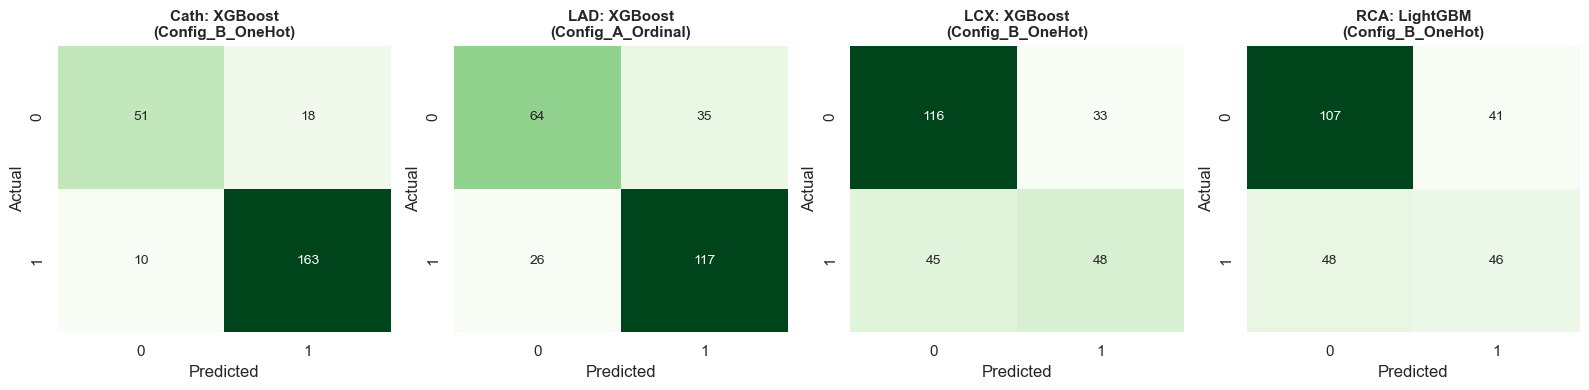

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, target in enumerate(TARGET_COLUMNS):
    best_m = summary_df[summary_df['target'] == target].sort_values('roc_auc_mean', ascending=False).iloc[0]
    oof_key = f"{target}__{best_m['preprocessing']}__{best_m['model']}"
    y_true = y_dev[target]
    y_pred = rep1_oof_dict[oof_key]['pred']

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False)
    axes[i].set_title(f"{target}: {best_m['model']}\n({best_m['preprocessing']})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 17. Model Probability Agreement Analysis
Audit correlation and prediction agreement between out-of-fold predicted probabilities for XGBoost and LightGBM across targets. This diagnostic evaluation is strictly based on the representative first 5-fold repetition on the 242-patient development set.

In [17]:
agreement_records = []

for target in TARGET_COLUMNS:
    xgb_key = f"{target}__Config_A_Ordinal__XGBoost"
    lgb_key = f"{target}__Config_A_Ordinal__LightGBM"

    prob_xgb = rep1_oof_dict[xgb_key]['prob']
    prob_lgb = rep1_oof_dict[lgb_key]['prob']

    r_pearson, _ = pearsonr(prob_xgb, prob_lgb)
    r_spearman, _ = spearmanr(prob_xgb, prob_lgb)
    pred_agreement = (rep1_oof_dict[xgb_key]['pred'] == rep1_oof_dict[lgb_key]['pred']).mean() * 100

    agreement_records.append({
        'Target': target,
        'Comparison': 'XGBoost vs LightGBM (Config A)',
        'Pearson r': round(r_pearson, 3),
        'Spearman rho': round(r_spearman, 3),
        'Label Agreement %': round(pred_agreement, 2)
    })

agreement_df = pd.DataFrame(agreement_records)
display(agreement_df)

,Target,Comparison,Pearson r,Spearman rho,Label Agreement %
0,Cath,XGBoost vs LightGBM (Config A),0.980,0.974,95.87
1,LAD,XGBoost vs LightGBM (Config A),0.966,0.969,94.21
2,LCX,XGBoost vs LightGBM (Config A),0.946,0.950,92.56
3,RCA,XGBoost vs LightGBM (Config A),0.918,0.925,90.08


## 18. Notebook 5 Tuning Candidate Selection
Construct a deduplicated candidate shortlist of top models (best ROC-AUC, best F1, and best Recall) for selective hyperparameter optimization in Notebook 5.

In [18]:
tuning_candidates = []

# Merge baseline summary and boosting summary for unified candidate pool
combined_summary = pd.concat([
    nb3_summary[['target', 'model', 'preprocessing', 'roc_auc_mean', 'roc_auc_std', 'f1_mean', 'f1_std', 'recall_mean', 'recall_std']],
    summary_df[['target', 'model', 'preprocessing', 'roc_auc_mean', 'roc_auc_std', 'f1_mean', 'f1_std', 'recall_mean', 'recall_std']]
], ignore_index=True)

for target in TARGET_COLUMNS:
    t_pool = combined_summary[combined_summary['target'] == target]

    best_auc = t_pool.sort_values('roc_auc_mean', ascending=False).iloc[0]
    best_f1 = t_pool.sort_values('f1_mean', ascending=False).iloc[0]
    best_rec = t_pool.sort_values('recall_mean', ascending=False).iloc[0]

    seen = set()
    for row, criterion in [(best_auc, 'Best ROC-AUC'), (best_f1, 'Best F1'), (best_rec, 'Best Recall')]:
        key = (row['model'], row['preprocessing'])
        if key not in seen:
            seen.add(key)
            tuning_candidates.append({
                'Target': target,
                'Candidate Criterion': criterion,
                'Model': row['model'],
                'Preprocessing': row['preprocessing'],
                'ROC-AUC': f"{row['roc_auc_mean']:.3f} +/- {row['roc_auc_std']:.3f}",
                'F1': f"{row['f1_mean']:.3f} +/- {row['f1_std']:.3f}",
                'Recall': f"{row['recall_mean']:.3f} +/- {row['recall_std']:.3f}"
            })

tuning_candidates_df = pd.DataFrame(tuning_candidates)
print("Notebook 5 Candidate Shortlist for Selective Tuning:")
display(tuning_candidates_df)

Notebook 5 Candidate Shortlist for Selective Tuning:


,Target,Candidate Criterion,Model,Preprocessing,ROC-AUC,F1,Recall
0,Cath,Best ROC-AUC,RandomForest,Config_B_OneHot,0.932 +/- 0.039,0.912 +/- 0.026,0.947 +/- 0.039
1,Cath,Best F1,XGBoost,Config_B_OneHot,0.925 +/- 0.039,0.914 +/- 0.028,0.936 +/- 0.042
2,LAD,Best ROC-AUC,RandomForest,Config_A_Ordinal,0.854 +/- 0.056,0.845 +/- 0.046,0.899 +/- 0.047
3,LCX,Best ROC-AUC,XGBoost,Config_B_OneHot,0.750 +/- 0.064,0.549 +/- 0.095,0.515 +/- 0.131
4,LCX,Best F1,XGBoost,Config_A_Ordinal,0.747 +/- 0.063,0.557 +/- 0.090,0.521 +/- 0.128
5,LCX,Best Recall,LightGBM,Config_B_OneHot,0.728 +/- 0.070,0.552 +/- 0.085,0.530 +/- 0.131
6,RCA,Best ROC-AUC,LogisticRegression,Config_A_Ordinal,0.719 +/- 0.057,0.546 +/- 0.087,0.518 +/- 0.110


## 19. Save Experiment Artifacts
Persist long-form fold metrics, summary tables, and metadata.

In [19]:
boosting_results_df.to_csv('artifacts/notebook4_boosting_fold_results.csv', index=False)
summary_df.to_csv('artifacts/notebook4_boosting_summary.csv', index=False)
prep_sens_df.to_csv('artifacts/notebook4_boosting_preprocessing_comparison.csv')
vs_baseline_df.to_csv('artifacts/notebook4_vs_baseline_comparison.csv', index=False)
agreement_df.to_csv('artifacts/notebook4_model_agreement.csv', index=False)
tuning_candidates_df.to_csv('artifacts/notebook4_tuning_candidates.csv', index=False)

metadata = {
    'notebook': '04_Boosting_Models.ipynb',
    'total_evaluations': len(boosting_results_df),
    'development_cohort_size': len(X_dev),
    'holdout_cohort_size': len(X_holdout),
    'targets_evaluated': TARGET_COLUMNS,
    'boosting_models': list(BOOSTING_MODELS.keys()),
    'preprocessing_configurations': list(PREPROCESSORS.keys()),
    'holdout_status': 'SEALED_UNTOUCHED'
}

with open('artifacts/notebook4_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Saved all Notebook 4 experiment artifacts to artifacts/ directory.")

Saved all Notebook 4 experiment artifacts to artifacts/ directory.


## 20. Final Findings & Handoff to Notebook 5
All numbers below are generated from the summary tables above (no hand-typed values). Statements are descriptive comparisons from repeated cross-validation on the development cohort.

In [20]:
best_boost = summary_df.sort_values('roc_auc_mean', ascending=False).groupby('target').head(1).set_index('target')
best_base = nb3_summary.sort_values('roc_auc_mean', ascending=False).groupby('target').head(1).set_index('target')

findings_rows = []
for target in TARGET_COLUMNS:
    b, g = best_base.loc[target], best_boost.loc[target]
    findings_rows.append({
        'Question': f'{target}: best boosting vs best Notebook 3 baseline',
        'Conclusion': (f"Baseline {b['model']} ({b['preprocessing']}): ROC-AUC {b['roc_auc_mean']:.3f} +/- {b['roc_auc_std']:.3f}; "
                       f"boosting {g['model']} ({g['preprocessing']}): {g['roc_auc_mean']:.3f} +/- {g['roc_auc_std']:.3f}; "
                       f"delta {g['roc_auc_mean'] - b['roc_auc_mean']:+.3f}. This is small relative to the fold-to-fold SD.")
    })

prep_abs = prep_sens_df['Delta_ROC_AUC'].abs()
findings_rows.append({
    'Question': 'Preprocessing Config A vs B (boosting)',
    'Conclusion': f"Largest absolute mean ROC-AUC difference = {prep_abs.max():.4f} ({prep_abs.idxmax()[0]}, {prep_abs.idxmax()[1]})."
})
findings_rows.append({
    'Question': 'Candidates exported for Notebook 5',
    'Conclusion': (f"{len(tuning_candidates_df)} deduplicated candidates (best ROC-AUC / F1 / Recall per target) were written to "
                   "artifacts/notebook4_tuning_candidates.csv. Notebook 5 documents its final candidate list and rationale separately.")
})
findings_rows.append({'Question': 'Holdout status', 'Conclusion': 'The 61-patient holdout was not used in this notebook.'})

findings = pd.DataFrame(findings_rows)
with pd.option_context('display.max_colwidth', None):
    display(findings)
print("Notebook 4 complete. Handoff contract ready for Notebook 5 (Selective Hyperparameter Tuning).")

,Question,Conclusion
0,Cath: best boosting vs best Notebook 3 baseline,Baseline RandomForest (Config_B_OneHot): ROC-AUC 0.932 +/- 0.039; boosting XGBoost (Config_B_OneHot): 0.925 +/- 0.039; delta -0.008. This is small relative to the fold-to-fold SD.
1,LAD: best boosting vs best Notebook 3 baseline,Baseline RandomForest (Config_A_Ordinal): ROC-AUC 0.854 +/- 0.056; boosting XGBoost (Config_A_Ordinal): 0.831 +/- 0.051; delta -0.023. This is small relative to the fold-to-fold SD.
2,LCX: best boosting vs best Notebook 3 baseline,Baseline RandomForest (Config_B_OneHot): ROC-AUC 0.745 +/- 0.055; boosting XGBoost (Config_B_OneHot): 0.750 +/- 0.064; delta +0.005. This is small relative to the fold-to-fold SD.
3,RCA: best boosting vs best Notebook 3 baseline,Baseline LogisticRegression (Config_A_Ordinal): ROC-AUC 0.719 +/- 0.057; boosting LightGBM (Config_B_OneHot): 0.686 +/- 0.059; delta -0.033. This is small relative to the fold-to-fold SD.
4,Preprocessing Config A vs B (boosting),"Largest absolute mean ROC-AUC difference = 0.0102 (LCX, LightGBM)."
5,Candidates exported for Notebook 5,7 deduplicated candidates (best ROC-AUC / F1 / Recall per target) were written to artifacts/notebook4_tuning_candidates.csv. Notebook 5 documents its final candidate list and rationale separately.
6,Holdout status,The 61-patient holdout was not used in this notebook.


Notebook 4 complete. Handoff contract ready for Notebook 5 (Selective Hyperparameter Tuning).
